<a href="https://colab.research.google.com/github/satyapal2240/1_for_conference_HSCF_A_Lightweight_and.ipynb/blob/main/hindi_sentiment_%2B_wala.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automated Sentiment Analysis of Hindi Text using Machine Learning

**Companion notebook — Hindi Sentiment Classification Framework (HSCF)**

Reproduces the full experimental pipeline: TF-IDF (unigram + bigram) features, Multinomial
Naive Bayes and Logistic Regression with validation-based hyperparameter tuning, 5-fold
stratified cross-validation with a paired t-test, and a fine-tuned mBERT transformer baseline,
on the IIT Patna Movie Reviews Hindi Sentiment Analysis dataset
(2,480 train / 310 validation / 310 test; negative, neutral, positive).

**How to run:** `Runtime -> Run all`. Nothing else is required. Every cell is defensive —
missing packages are installed, the dataset is fetched through a cascade of five fallbacks,
and if the transformer stage cannot run it is skipped cleanly rather than aborting the notebook.

**For mBERT:** set `Runtime -> Change runtime type -> T4 GPU` first. Without a GPU the
transformer section still runs, but takes roughly 30-50 minutes instead of 2-4.

Outputs (tables as CSV, figures as 300-dpi PNG, trained models as `.pkl`) are written to
`hscf_outputs/` and bundled into a single downloadable zip by the last cell.

## 1. Environment setup

Installs only what is actually missing. Safe to re-run.

In [ ]:
import importlib, subprocess, sys, warnings
warnings.filterwarnings("ignore")

def ensure(module, pip_name=None, install=True):
    '''Import a module, pip-installing it first if needed. Returns True on success.'''
    try:
        importlib.import_module(module)
        return True
    except ImportError:
        if not install:
            return False
    pip_name = pip_name or module
    print(f"  installing {pip_name} ...")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name],
                       check=True, capture_output=True)
        importlib.invalidate_caches()
        importlib.import_module(module)
        print(f"  {pip_name} ready")
        return True
    except Exception as exc:
        print(f"  could not install {pip_name}: {type(exc).__name__}")
        return False

print("Core packages")
CORE_OK = all([
    ensure("numpy"), ensure("pandas"), ensure("sklearn", "scikit-learn"),
    ensure("scipy"), ensure("matplotlib"), ensure("joblib"),
])
if not CORE_OK:
    raise SystemExit("Core scientific stack unavailable - cannot continue.")

print("Optional packages")
HAS_SEABORN = ensure("seaborn")
HAS_HF_HUB  = ensure("huggingface_hub")
HAS_DATASETS = ensure("datasets")
ensure("kagglehub")   # only used if a Kaggle API token is configured; harmless otherwise
# torch is pre-installed on Colab and is a very large download elsewhere, so it is
# never auto-installed; transformers is small enough to fetch on demand.
HAS_TORCH = ensure("torch", install=False)
HAS_TRANSFORMERS = ensure("transformers") if HAS_TORCH else False

print("\nSummary:", {
    "seaborn": HAS_SEABORN, "huggingface_hub": HAS_HF_HUB, "datasets": HAS_DATASETS,
    "torch": HAS_TORCH, "transformers": HAS_TRANSFORMERS,
})
if not HAS_TORCH:
    print("torch not found -> the mBERT section will be skipped. "
          "Install it with: pip install torch")

Core packages
Optional packages

Summary: {'seaborn': True, 'huggingface_hub': True, 'datasets': True, 'torch': True, 'transformers': True}


## 2. Imports, configuration and reproducibility

Every knob used anywhere in the notebook lives in this cell.

In [ ]:
import os, re, json, random, time, tarfile, zipfile, io, glob, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, roc_curve, auc)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
import joblib

# ----------------------------- configuration ---------------------------------
RANDOM_STATE   = 42
LABEL_NAMES    = ["negative", "neutral", "positive"]     # index == integer label
OUTDIR         = Path("hscf_outputs"); OUTDIR.mkdir(exist_ok=True)

# TF-IDF (Section III.A of the paper)
TFIDF_KW = dict(ngram_range=(1, 2), max_df=0.95, min_df=2,
                sublinear_tf=True, norm="l2")

# Validation-tuned hyperparameter grids
MNB_ALPHA_GRID = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
LR_C_GRID      = [0.5, 1.0, 3.0, 5.0, 10.0]
LR_WEIGHT_GRID = [None, "balanced"]

# Cross-validation
N_FOLDS = 5

# mBERT
RUN_MBERT      = True                      # set False to skip the transformer entirely
MBERT_MODEL    = "bert-base-multilingual-cased"
MBERT_EPOCHS   = 4
MBERT_BATCH    = 16
MBERT_LR       = 2e-5
MBERT_MAXLEN   = 128
MBERT_WD       = 0.01
MBERT_WARMUP   = 0.10

# Optional: point this at a folder holding hi-train/hi-valid/hi-test files to load locally
LOCAL_DATA_DIR = "/content/data"
# -----------------------------------------------------------------------------

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
                     "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

RESULTS = {}          # collects every metric produced by the notebook
DEMO_MODE = False     # flipped to True only if the real dataset cannot be reached

def save_table(df, name, caption=""):
    '''Persist a results table to CSV and display it.'''
    path = OUTDIR / f"{name}.csv"
    df.to_csv(path, index=False)
    if caption:
        print(caption)
    try:
        from IPython.display import display
        display(df)
    except Exception:
        print(df.to_string(index=False))
    return df

def save_fig(fig, name):
    path = OUTDIR / f"{name}.png"
    fig.savefig(path)
    print(f"  saved {path}")
    return path

print(f"Ready. numpy {np.__version__} | pandas {pd.__version__}")
print(f"Outputs -> {OUTDIR.resolve()}")

Ready. numpy 2.1.3 | pandas 2.2.3
Outputs -> /content/hscf_outputs


## 3. Dataset loading

The IIT Patna Movie Reviews Hindi dataset is fetched through five strategies, tried in order.
The first one that yields a usable train/validation/test triple wins:

1. **Kaggle API** (`kagglehub`) — the same source used by the paper's reference notebook,
   `warcoder/iit-patna-movie-reviews-hindi`. This is the **most reliable option** but needs a
   free Kaggle API token. To enable it:
   - Go to kaggle.com -> your profile picture -> *Settings* -> *API* -> **Create New Token**.
     This downloads `kaggle.json`.
   - In Colab, run in a new cell: `from google.colab import files; files.upload()` and pick that
     file, then `!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json`.
   - Re-run this cell. If no token is configured this strategy is skipped automatically —
     nothing breaks.
2. **Hugging Face `datasets`** — `ai4bharat/IndicGLUE`, configuration `iitp-mr.hi` (kept for
   completeness; as of writing this loading script has been deprecated upstream, so expect it
   to fail and fall through quickly).
3. **Hugging Face Hub parquet files** — read directly, bypassing the loading script.
4. **AI4Bharat public archive** — `classification_public_datasets.tgz`, the current official
   download link published in the AI4Bharat `indicnlp_corpus` GitHub README.
5. **Local files** — anything matching `*train*/*valid*/*test*` in `LOCAL_DATA_DIR`, the working
   directory, `/content`, or a Kaggle input folder. Column names, header presence, delimiter and
   line format (CSV/TSV, or one-label-per-line) are all auto-detected.
6. **Synthetic demo corpus** — a last resort so the notebook always runs end to end. It sets
   `DEMO_MODE = True` and prints a loud banner; numbers will *not* match the paper. **If you see
   this banner, do not trust any results below it** — set up the Kaggle token (option 1) or
   download manually (see the banner text) and re-run this cell.

In [11]:
from google.colab import files
uploaded = files.upload()

import os, shutil
os.makedirs("/content/data", exist_ok=True)
for fname in uploaded.keys():
    shutil.move(fname, f"/content/data/{fname}")
print("Moved:", list(uploaded.keys()))

Saving hi-test.csv to hi-test (3).csv
Saving hi-train.csv to hi-train (3).csv
Saving hi-valid.csv to hi-valid (3).csv
Moved: ['hi-test (3).csv', 'hi-train (3).csv', 'hi-valid (3).csv']


In [12]:
def _looks_like_label(series):
    '''A label column has few distinct values and no long strings.'''
    vals = series.dropna().astype(str)
    if len(vals) == 0:
        return False
    return vals.nunique() <= 12 and vals.str.len().max() <= 12

def _coerce_labels(series):
    '''Map whatever the label column holds onto 0/1/2 (negative/neutral/positive).'''
    s = series.copy()
    if pd.api.types.is_numeric_dtype(s):
        ints = s.astype(int)
        uniq = sorted(ints.unique())
        if set(uniq) <= {0, 1, 2}:
            return ints
        if set(uniq) <= {-1, 0, 1}:            # -1/0/1 convention
            return ints.map({-1: 0, 0: 1, 1: 2})
        if set(uniq) <= {1, 2, 3}:             # 1-indexed convention
            return ints - 1
        raise ValueError(f"unrecognised numeric labels: {uniq}")
    txt = s.astype(str).str.strip().str.lower()
    mapping = {"negative": 0, "neg": 0, "0": 0, "-1": 0,
               "neutral": 1, "neu": 1, "1": 1,
               "positive": 2, "pos": 2, "2": 2}
    out = txt.map(mapping)
    if out.isna().any():
        raise ValueError(f"unrecognised text labels: {sorted(txt[out.isna()].unique())[:5]}")
    return out.astype(int)

def standardize(df):
    '''Return a DataFrame with exactly two columns: text (str) and label (0/1/2).'''
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]

    text_col = next((c for c in ("text", "review", "sentence", "content", "comment")
                     if c in df.columns), None)
    label_col = next((c for c in ("label", "labels", "sentiment", "class", "target", "polarity")
                      if c in df.columns), None)

    if text_col is None or label_col is None:      # fall back to shape-based detection
        cand = [c for c in df.columns if c not in (text_col, label_col)]
        if label_col is None:
            label_col = next((c for c in cand if _looks_like_label(df[c])), None)
            cand = [c for c in cand if c != label_col]
        if text_col is None:
            lengths = {c: df[c].astype(str).str.len().mean() for c in cand}
            text_col = max(lengths, key=lengths.get) if lengths else None

    if text_col is None or label_col is None:
        raise ValueError(f"could not identify text/label columns in {list(df.columns)}")

    out = pd.DataFrame({"text": df[text_col].astype(str),
                        "label": _coerce_labels(df[label_col])})
    return out.reset_index(drop=True)

def read_table_flexible(path):
    '''Read a csv/tsv/json/parquet/txt file whether or not it carries a header row.'''
    path = str(path)
    if path.endswith(".parquet"):
        return pd.read_parquet(path)
    if path.endswith((".json", ".jsonl")):
        return pd.read_json(path, lines=path.endswith(".jsonl"))
    if path.endswith(".txt"):
        with open(path, encoding="utf-8", errors="replace") as fh:
            sample = fh.read(4096)
        import csv as _csv
        try:
            sep = _csv.Sniffer().sniff(sample, delimiters="\t,|").delimiter
        except Exception:
            sep = "\t" if "\t" in sample else ","
        df = pd.read_csv(path, sep=sep, header=None, engine="python",
                         on_bad_lines="skip", encoding="utf-8")
    else:
        sep = "\t" if path.endswith((".tsv", ".tab")) else ","
        df = pd.read_csv(path, sep=sep)
        header_looks_like_data = not any(
            str(c).strip().lower() in {"text", "label", "labels", "sentiment", "review", "class"}
            for c in df.columns)
        if header_looks_like_data:
            df_nohdr = pd.read_csv(path, sep=sep, header=None)
            if df_nohdr.shape[1] == df.shape[1]:
                df = df_nohdr
    return df

def parse_fasttext_style(path):
    '''fastText-style lines: "__label__positive some text" or "positive\tsome text".'''
    rows = []
    with open(path, encoding="utf-8", errors="replace") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            m = re.match(r"__label__(\S+)\s+(.*)", line)
            if m:
                rows.append({"label": m.group(1), "text": m.group(2)})
                continue
            parts = re.split(r"\t", line, maxsplit=1)
            if len(parts) == 2 and len(parts[0]) <= 12:
                rows.append({"label": parts[0], "text": parts[1]})
    if not rows:
        raise ValueError("no fastText-style / label-prefixed lines found")
    return pd.DataFrame(rows)

def load_any_labeled_file(path):
    '''Best-effort loader: tabular formats first, fastText-style lines as fallback.'''
    try:
        return standardize(read_table_flexible(path))
    except Exception as tabular_exc:
        try:
            return standardize(parse_fasttext_style(path))
        except Exception:
            raise tabular_exc

In [13]:
def _kaggle_available():
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        return True
    for p in (Path.home() / ".kaggle" / "kaggle.json", Path("/root/.kaggle/kaggle.json")):
        if p.exists():
            return True
    return False

def _from_kaggle():
    ensure("kagglehub")
    import kagglehub
    root = kagglehub.dataset_download("warcoder/iit-patna-movie-reviews-hindi")
    return _from_local(root)

def _from_hf_datasets():
    from datasets import load_dataset
    ds = load_dataset("ai4bharat/IndicGLUE", "iitp-mr.hi")
    splits = {"train": "train", "val": "validation", "test": "test"}
    out = {}
    for key, name in splits.items():
        if name not in ds:
            name = {"validation": "valid", "test": "test"}.get(name, name)
        out[key] = standardize(ds[name].to_pandas())
    return out

def _from_hf_parquet():
    from huggingface_hub import HfApi, hf_hub_download
    files = HfApi().list_repo_files("ai4bharat/IndicGLUE", repo_type="dataset")
    wanted = [f for f in files if "iitp-mr.hi" in f and f.endswith(".parquet")]
    if not wanted:
        raise FileNotFoundError("no iitp-mr.hi parquet files on the Hub")
    buckets = {"train": [], "val": [], "test": []}
    for f in wanted:
        low = f.lower()
        key = "val" if ("valid" in low or "/validation" in low) else ("test" if "test" in low else "train")
        buckets[key].append(f)
    out = {}
    for key, paths in buckets.items():
        if not paths:
            raise FileNotFoundError(f"missing {key} parquet")
        frames = [pd.read_parquet(hf_hub_download("ai4bharat/IndicGLUE", p, repo_type="dataset"))
                  for p in sorted(paths)]
        out[key] = standardize(pd.concat(frames, ignore_index=True))
    return out

def _from_tarball():
    import urllib.request
    # Current official link, per the AI4Bharat/indicnlp_corpus GitHub README
    # ("Publicly available Classification Datasets" section).
    url = ("https://storage.googleapis.com/ai4bharat-public-indic-nlp-corpora/"
           "evaluations/classification/classification_public_datasets.tgz")
    workdir = Path("_ai4bharat_raw"); workdir.mkdir(exist_ok=True)
    local = workdir / "classification_public_datasets.tgz"
    print(f"  downloading {url}")
    urllib.request.urlretrieve(url, local)
    with tarfile.open(local) as tf:
        tf.extractall(workdir)
    # This archive bundles many languages/datasets - bias the search toward Hindi movie reviews.
    return _from_local(str(workdir), hints=("iitp", "movie", "mr", "hi"))

def _score(path_lower, hints):
    return sum(1 for h in hints if h in path_lower)

def _from_local(root=None, hints=()):
    roots = [r for r in [root, LOCAL_DATA_DIR, ".", "/content", "/content/data",
                         "/kaggle/input", str(Path.home())] if r and Path(r).exists()]
    exts = ("csv", "tsv", "txt", "json", "jsonl", "parquet")
    for r in roots:
        candidates = {"train": [], "val": [], "test": []}
        for ext in exts:
            for p in glob.glob(f"{r}/**/*.{ext}", recursive=True):
                low = p.lower()
                name = Path(p).name.lower()
                if "train" in name:
                    candidates["train"].append(p)
                elif ("valid" in name or name.startswith("dev") or "-dev" in name):
                    candidates["val"].append(p)
                elif "test" in name:
                    candidates["test"].append(p)
        if not all(candidates.values()):
            continue
        found = {}
        for key, paths in candidates.items():
            ranked = sorted(paths, key=lambda p: -_score(p.lower(), hints)) if hints else paths
            for p in ranked:
                try:
                    df = load_any_labeled_file(p)
                    if len(df) > 0:
                        found[key] = (p, df)
                        break
                except Exception:
                    continue
        if {"train", "val", "test"} <= set(found):
            print(f"  found local files under {r}: "
                  f"{ {k: Path(v[0]).name for k, v in found.items()} }")
            return {k: v[1] for k, v in found.items()}
    raise FileNotFoundError("no local train/valid/test triple found")


def _synthetic():
    '''Template-generated stand-in with the paper's split sizes and class balance.'''
    rng = np.random.default_rng(RANDOM_STATE)
    pos = ["यह फिल्म बहुत अच्छी है", "शानदार अभिनय और बेहतरीन निर्देशन",
           "कहानी दिल को छू लेने वाली है", "संगीत लाजवाब है और गाने मधुर हैं",
           "एक बार जरूर देखनी चाहिए", "अद्भुत सिनेमैटोग्राफी और उम्दा पटकथा"]
    neg = ["यह फिल्म बहुत खराब है", "कमजोर पटकथा और बोरिंग निर्देशन",
           "समय की बर्बादी है", "अभिनय बेहद निराशाजनक रहा",
           "कहानी में कोई दम नहीं है", "संवाद बेकार और संपादन ढीला है"]
    neu = ["फिल्म ठीक ठाक है", "कुछ दृश्य अच्छे हैं कुछ सामान्य",
           "कहानी पुरानी है पर प्रस्तुति नई है", "औसत दर्जे की फिल्म है",
           "निर्देशन सामान्य है अभिनय भी ठीक है", "एक बार देखी जा सकती है"]
    extra = ["", " कुल मिलाकर", " दर्शकों के लिए", " मेरी राय में", " फिल्म समीक्षा"]
    def build(counts):
        rows = []
        for lbl, n in counts.items():
            base = {0: neg, 1: neu, 2: pos}[lbl]
            for i in range(n):
                rows.append({"text": rng.choice(base) + rng.choice(extra) + f" {i%17}",
                             "label": lbl})
        df = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE)
        return df.reset_index(drop=True)
    return {"train": build({0: 741, 1: 697, 2: 1042}),
            "val":   build({0: 98,  1: 90,  2: 122}),
            "test":  build({0: 98,  1: 90,  2: 122})}

STRATEGIES = [
    ("Kaggle API (warcoder/iit-patna-movie-reviews-hindi)", _from_kaggle, _kaggle_available()),
    ("Hugging Face datasets (ai4bharat/IndicGLUE, iitp-mr.hi)", _from_hf_datasets, HAS_DATASETS),
    ("Hugging Face Hub parquet files",                          _from_hf_parquet,  HAS_HF_HUB),
    ("AI4Bharat public archive (classification_public_datasets.tgz)", _from_tarball, True),
    ("Local train/valid/test files",                            _from_local,       True),
]

data, SOURCE = None, None
for name, fn, available in STRATEGIES:
    if not available:
        reason = ("no Kaggle API token found - see the setup steps above" if "Kaggle API" in name
                  else "dependency missing")
        print(f"[skip] {name} ({reason})")
        continue
    print(f"[try ] {name}")
    try:
        data = fn()
        SOURCE = name
        print(f"[ ok ] loaded via {name}\n")
        break
    except Exception as exc:
        print(f"[fail] {type(exc).__name__}: {str(exc)[:160]}")

if data is None:
    DEMO_MODE = True
    data = _synthetic()
    SOURCE = "synthetic demo corpus"
    print("\n" + "!" * 78)
    print("! DEMO MODE - the real IIT Patna dataset could not be downloaded.")
    print("! The notebook will run end to end on a synthetic stand-in corpus, but the")
    print("! numbers below will NOT reproduce the paper. To get the real data either:")
    print("!   - restore internet access and re-run this cell, or")
    print("!   - download the dataset from")
    print("!     https://www.kaggle.com/code/khushipitroda/iit-patna-movie-reviews-hindi-sentiment-analysis")
    print("!     and set LOCAL_DATA_DIR in the configuration cell to its folder.")
    print("!" * 78 + "\n")

train_df, val_df, test_df = data["train"], data["val"], data["test"]
for split, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{split:<11} {len(df):>5} rows")
train_df.head(3)

[skip] Kaggle API (warcoder/iit-patna-movie-reviews-hindi) (no Kaggle API token found - see the setup steps above)
[try ] Hugging Face datasets (ai4bharat/IndicGLUE, iitp-mr.hi)
[fail] DatasetNotFoundError: Dataset 'ai4bharat/IndicGLUE' doesn't exist on the Hub or cannot be accessed.
[try ] Hugging Face Hub parquet files
[fail] RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-6aae525f-49a952307f5cd1b11ad69905;f79d6ec2-a198-4a84-a2a4-2b91a51f44c5)

Repository Not Found for url: https://huggingface
[try ] AI4Bharat public archive (classification_public_datasets.tgz)
  downloading https://storage.googleapis.com/ai4bharat-public-indic-nlp-corpora/evaluations/classification/classification_public_datasets.tgz
[fail] HTTPError: HTTP Error 403: Forbidden
[try ] Local train/valid/test files
  found local files under /content/data: {'train': 'hi-train (3).csv', 'val': 'hi-valid (3).csv', 'test': 'hi-test (3).csv'}
[ ok ] loaded via Local train/valid/test files

train        2480 ro

,text,label
0,"निर्माता :\nशीतल विनोद तलवार, मधु‍ मैंटेना\n\n...",1
1,’उड़ान’ से विक्रमादित्य\nमोटवाने\nने अच्छे सिन...,2
2,फिल्म में गानों के दृश्य में अनुष्का को माइक क...,1


## 4. Preprocessing

The four operations described in Section III.A: missing-value removal, Unicode normalization of
the Devanagari script, newline removal, and redundant-whitespace collapsing.

In [14]:
import unicodedata

def clean(text):
    '''Composite preprocessing function clean(T) from Section III.A.'''
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""
    t = unicodedata.normalize("NFC", str(text))   # Devanagari Unicode standardization
    t = t.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    t = re.sub(r"\s+", " ", t)                     # collapse redundant whitespace
    return t.strip()

def preprocess(df, name):
    before = len(df)
    out = df.copy()
    out["text"] = out["text"].map(clean)
    out = out[(out["text"].str.len() > 0) & out["label"].notna()]
    out["label"] = out["label"].astype(int)
    out = out.reset_index(drop=True)
    print(f"{name:<11} {before} -> {len(out)} rows ({before - len(out)} empty/missing removed)")
    return out

train_df = preprocess(train_df, "train")
val_df   = preprocess(val_df,   "validation")
test_df  = preprocess(test_df,  "test")

dist = pd.DataFrame({
    split: pd.Series(df["label"].value_counts()).reindex([0, 1, 2]).fillna(0).astype(int).values
    for split, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]
}, index=LABEL_NAMES).reset_index().rename(columns={"index": "Class"})
save_table(dist, "class_distribution", "\nClass distribution per split:")

expected = {"train": 2480, "val": 310, "test": 310}
actual = {"train": len(train_df), "val": len(val_df), "test": len(test_df)}
if DEMO_MODE:
    print("\nDemo corpus: split sizes and class balance mirror the paper, but the text is "
          "synthetic, so the metrics below are placeholders - not a reproduction.")
elif actual == expected:
    print("\nSplit sizes match the paper exactly (2480 / 310 / 310).")
else:
    print(f"\nNote: split sizes are {actual}; the paper reports {expected}.")

X_train_txt, y_train = train_df["text"].values, train_df["label"].values
X_val_txt,   y_val   = val_df["text"].values,   val_df["label"].values
X_test_txt,  y_test  = test_df["text"].values,  test_df["label"].values

train       2480 -> 2480 rows (0 empty/missing removed)
validation  310 -> 310 rows (0 empty/missing removed)
test        310 -> 310 rows (0 empty/missing removed)

Class distribution per split:


,Class,Train,Validation,Test
0,negative,741,109,98
1,neutral,697,80,90
2,positive,1042,121,122



Split sizes match the paper exactly (2480 / 310 / 310).


## 5. TF-IDF feature extraction

Unigrams and bigrams, `max_df=0.95`, `min_df=2`, sublinear term-frequency scaling, L2
normalization. The vectorizer is fitted on the training partition **only**; validation and test
are transformed with that fitted vocabulary, so no information leaks across partitions.

In [15]:
vectorizer = TfidfVectorizer(**TFIDF_KW)
X_train = vectorizer.fit_transform(X_train_txt)
X_val   = vectorizer.transform(X_val_txt)
X_test  = vectorizer.transform(X_test_txt)

print(f"Vocabulary size : {len(vectorizer.vocabulary_):,} features")
print(f"Train matrix    : {X_train.shape[0]:,} x {X_train.shape[1]:,}")
print(f"Validation      : {X_val.shape[0]:,} x {X_val.shape[1]:,}")
print(f"Test            : {X_test.shape[0]:,} x {X_test.shape[1]:,}")
print(f"Sparsity        : {100 * (1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])):.3f}% zeros")
RESULTS["vocab_size"] = int(X_train.shape[1])

Vocabulary size : 30,228 features
Train matrix    : 2,480 x 30,228
Validation      : 310 x 30,228
Test            : 310 x 30,228
Sparsity        : 99.608% zeros


## 6. Validation-based hyperparameter tuning

The 310-sample validation partition is used for principled model selection, exactly as in
Section III.A: the MNB Laplace-smoothing parameter `alpha` and the LR inverse-regularization
strength `C` (under both uniform and class-balanced weighting) are searched, and the
configuration with the highest validation accuracy is kept. The test partition is not touched.

In [16]:
print("Multinomial Naive Bayes - alpha search")
mnb_rows = []
for a in MNB_ALPHA_GRID:
    m = MultinomialNB(alpha=a).fit(X_train, y_train)
    acc = accuracy_score(y_val, m.predict(X_val))
    mnb_rows.append({"alpha": a, "val_accuracy": acc})
    print(f"  alpha={a:<5} validation accuracy = {acc:.4f}")
mnb_search = pd.DataFrame(mnb_rows)
BEST_ALPHA = float(mnb_search.loc[mnb_search.val_accuracy.idxmax(), "alpha"])
print(f"  -> selected alpha = {BEST_ALPHA}\n")

print("Logistic Regression - C / class_weight search")
lr_rows = []
for cw in LR_WEIGHT_GRID:
    for c in LR_C_GRID:
        m = LogisticRegression(C=c, class_weight=cw, solver="lbfgs",
                               max_iter=2000, random_state=RANDOM_STATE).fit(X_train, y_train)
        acc = accuracy_score(y_val, m.predict(X_val))
        lr_rows.append({"C": c, "class_weight": str(cw), "val_accuracy": acc})
        print(f"  C={c:<5} class_weight={str(cw):<9} validation accuracy = {acc:.4f}")
lr_search = pd.DataFrame(lr_rows)
best_lr = lr_search.loc[lr_search.val_accuracy.idxmax()]
BEST_C  = float(best_lr["C"])
BEST_CW = None if best_lr["class_weight"] == "None" else best_lr["class_weight"]
print(f"  -> selected C = {BEST_C}, class_weight = {BEST_CW}")

save_table(pd.concat([
    mnb_search.assign(model="MNB", setting="alpha=" + mnb_search.alpha.astype(str))[["model", "setting", "val_accuracy"]],
    lr_search.assign(model="LR", setting="C=" + lr_search.C.astype(str) + ", cw=" + lr_search.class_weight)[["model", "setting", "val_accuracy"]],
], ignore_index=True), "hyperparameter_search", "\nFull hyperparameter search:")
RESULTS["best_alpha"], RESULTS["best_C"], RESULTS["best_class_weight"] = BEST_ALPHA, BEST_C, str(BEST_CW)

Multinomial Naive Bayes - alpha search
  alpha=0.01  validation accuracy = 0.5226
  alpha=0.02  validation accuracy = 0.5290
  alpha=0.05  validation accuracy = 0.5387
  alpha=0.1   validation accuracy = 0.5258
  alpha=0.2   validation accuracy = 0.5097
  alpha=0.5   validation accuracy = 0.4645
  alpha=1.0   validation accuracy = 0.4323
  -> selected alpha = 0.05

Logistic Regression - C / class_weight search
  C=0.5   class_weight=None      validation accuracy = 0.5355
  C=1.0   class_weight=None      validation accuracy = 0.5613
  C=3.0   class_weight=None      validation accuracy = 0.5387
  C=5.0   class_weight=None      validation accuracy = 0.5452
  C=10.0  class_weight=None      validation accuracy = 0.5419
  C=0.5   class_weight=balanced  validation accuracy = 0.5742
  C=1.0   class_weight=balanced  validation accuracy = 0.5806
  C=3.0   class_weight=balanced  validation accuracy = 0.5742
  C=5.0   class_weight=balanced  validation accuracy = 0.5581
  C=10.0  class_weight=balan

,model,setting,val_accuracy
0,MNB,alpha=0.01,0.522581
1,MNB,alpha=0.02,0.529032
2,MNB,alpha=0.05,0.538710
3,MNB,alpha=0.1,0.525806
4,MNB,alpha=0.2,0.509677
5,MNB,alpha=0.5,0.464516
6,MNB,alpha=1.0,0.432258
7,LR,"C=0.5, cw=None",0.535484
8,LR,"C=1.0, cw=None",0.561290
9,LR,"C=3.0, cw=None",0.538710


## 7. Final training and overall performance (Tables I and II, Figure 1)

Both tuned models are refitted on the training partition and evaluated once on the held-out
test set.

Both models trained in 1.8s
TABLE I: Overall Performance of Classification Models


,Performance Metrics,Logistic Regression (LR),Naive Bayes (NB)
0,Accuracy (Test),56.45%,53.23%
1,Precision (Macro),0.5626,0.5386
2,Recall (Macro),0.5570,0.5126
3,F1-Score (Macro),0.5587,0.5122



TABLE II: Accuracy Across Data Partitions


,Model,Training,Validation,Test
0,Logistic Regression,95.20%,58.06%,56.45%
1,Naive Bayes,97.46%,53.87%,53.23%


  saved hscf_outputs/figure_1_accuracy_comparison.png


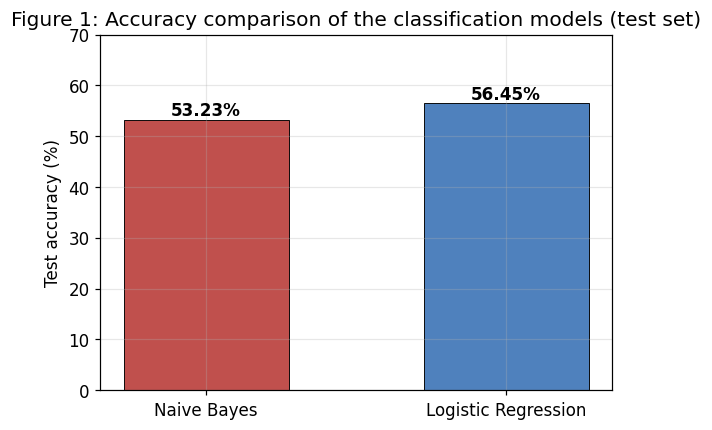

In [17]:
t0 = time.time()
nb_model = MultinomialNB(alpha=BEST_ALPHA).fit(X_train, y_train)
lr_model = LogisticRegression(C=BEST_C, class_weight=BEST_CW, solver="lbfgs",
                              max_iter=2000, random_state=RANDOM_STATE).fit(X_train, y_train)
print(f"Both models trained in {time.time() - t0:.1f}s")

def evaluate(model, X, y):
    pred = model.predict(X)
    acc = accuracy_score(y, pred)
    p, r, f, _ = precision_recall_fscore_support(y, pred, average="macro", zero_division=0)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f, "pred": pred}

nb_test = evaluate(nb_model, X_test, y_test)
lr_test = evaluate(lr_model, X_test, y_test)
nb_val, lr_val = evaluate(nb_model, X_val, y_val), evaluate(lr_model, X_val, y_val)
nb_tr,  lr_tr  = evaluate(nb_model, X_train, y_train), evaluate(lr_model, X_train, y_train)

table_1 = pd.DataFrame({
    "Performance Metrics": ["Accuracy (Test)", "Precision (Macro)", "Recall (Macro)", "F1-Score (Macro)"],
    "Logistic Regression (LR)": [f"{lr_test['accuracy']*100:.2f}%", f"{lr_test['precision']:.4f}",
                                 f"{lr_test['recall']:.4f}", f"{lr_test['f1']:.4f}"],
    "Naive Bayes (NB)":         [f"{nb_test['accuracy']*100:.2f}%", f"{nb_test['precision']:.4f}",
                                 f"{nb_test['recall']:.4f}", f"{nb_test['f1']:.4f}"],
})
save_table(table_1, "table_I_overall_performance", "TABLE I: Overall Performance of Classification Models")

table_2 = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Training":   [f"{lr_tr['accuracy']*100:.2f}%",   f"{nb_tr['accuracy']*100:.2f}%"],
    "Validation": [f"{lr_val['accuracy']*100:.2f}%",  f"{nb_val['accuracy']*100:.2f}%"],
    "Test":       [f"{lr_test['accuracy']*100:.2f}%", f"{nb_test['accuracy']*100:.2f}%"],
})
save_table(table_2, "table_II_accuracy_partitions", "\nTABLE II: Accuracy Across Data Partitions")

RESULTS["nb_test"] = {k: v for k, v in nb_test.items() if k != "pred"}
RESULTS["lr_test"] = {k: v for k, v in lr_test.items() if k != "pred"}

fig, ax = plt.subplots(figsize=(6, 4.2))
bars = ax.bar(["Naive Bayes", "Logistic Regression"],
              [nb_test["accuracy"] * 100, lr_test["accuracy"] * 100],
              color=["#c0504d", "#4f81bd"], width=0.55, edgecolor="black", linewidth=0.6)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8,
            f"{b.get_height():.2f}%", ha="center", fontweight="bold")
ax.set_ylabel("Test accuracy (%)"); ax.set_ylim(0, max(70, lr_test["accuracy"] * 100 + 12))
ax.set_title("Figure 1: Accuracy comparison of the classification models (test set)")
save_fig(fig, "figure_1_accuracy_comparison"); plt.show()

## 8. Classification reports (Tables III and IV)

In [18]:
def report_table(y_true, y_pred, title, fname):
    rep = classification_report(y_true, y_pred, target_names=LABEL_NAMES,
                                output_dict=True, zero_division=0)
    rows = []
    for cls in LABEL_NAMES:
        d = rep[cls]
        rows.append({"Class": cls, "Precision": round(d["precision"], 4),
                     "Recall": round(d["recall"], 4), "F1-Score": round(d["f1-score"], 4),
                     "Support": int(d["support"])})
    rows.append({"Class": "accuracy", "Precision": "—", "Recall": "—",
                 "F1-Score": round(rep["accuracy"], 4), "Support": len(y_true)})
    for key, name in [("macro avg", "macro avg"), ("weighted avg", "weighted avg")]:
        d = rep[key]
        rows.append({"Class": name, "Precision": round(d["precision"], 4),
                     "Recall": round(d["recall"], 4), "F1-Score": round(d["f1-score"], 4),
                     "Support": int(d["support"])})
    return save_table(pd.DataFrame(rows), fname, title), rep

_, nb_rep = report_table(y_test, nb_test["pred"],
                         "TABLE III: Classification Report of Naive Bayes (Test Set)",
                         "table_III_nb_report")
print()
_, lr_rep = report_table(y_test, lr_test["pred"],
                         "TABLE IV: Classification Report of Logistic Regression (Test Set)",
                         "table_IV_lr_report")

TABLE III: Classification Report of Naive Bayes (Test Set)


,Class,Precision,Recall,F1-Score,Support
0,negative,0.5882,0.4082,0.4819,98
1,neutral,0.507,0.4,0.4472,90
2,positive,0.5205,0.7295,0.6075,122
3,accuracy,—,—,0.5323,310
4,macro avg,0.5386,0.5126,0.5122,310
5,weighted avg,0.538,0.5323,0.5213,310



TABLE IV: Classification Report of Logistic Regression (Test Set)


,Class,Precision,Recall,F1-Score,Support
0,negative,0.6279,0.551,0.5870,98
1,neutral,0.4583,0.4889,0.4731,90
2,positive,0.6016,0.6311,0.6160,122
3,accuracy,—,—,0.5645,310
4,macro avg,0.5626,0.557,0.5587,310
5,weighted avg,0.5683,0.5645,0.5653,310


## 9. Confusion matrices (Table V, Figure 2)

TABLE V: Confusion Matrix of Logistic Regression (Test Set)


,True / Predicted,Pred negative,Pred neutral,Pred positive
0,True negative,54,22,22
1,True neutral,17,44,29
2,True positive,15,30,77


  saved hscf_outputs/figure_2_confusion_matrices.png


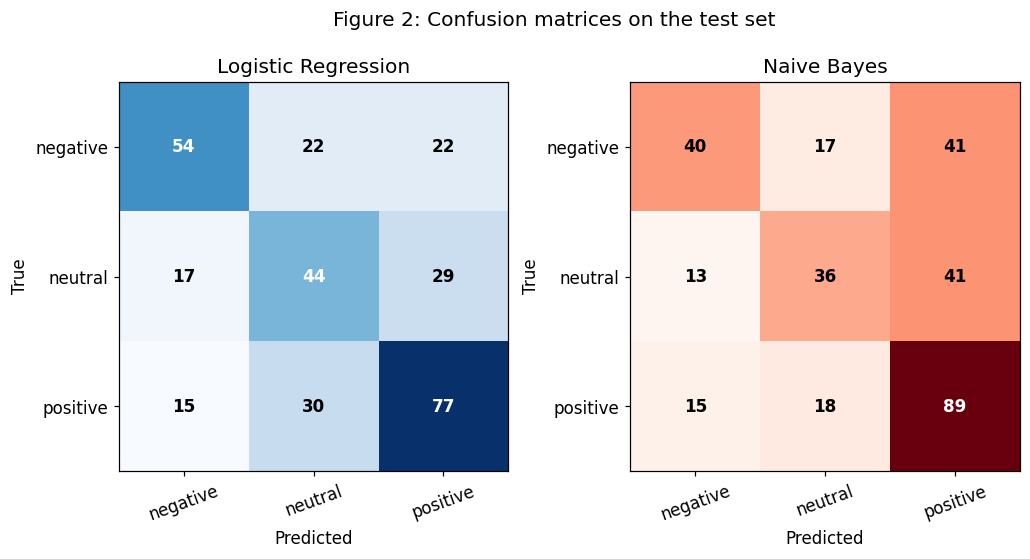


Per-class recall (LR): {'negative': '0.551', 'neutral': '0.489', 'positive': '0.631'}
Samples predicted positive by NB: 171 of 310


In [19]:
cm_lr = confusion_matrix(y_test, lr_test["pred"], labels=[0, 1, 2])
cm_nb = confusion_matrix(y_test, nb_test["pred"], labels=[0, 1, 2])

table_5 = pd.DataFrame(cm_lr, index=[f"True {c}" for c in LABEL_NAMES],
                       columns=[f"Pred {c}" for c in LABEL_NAMES]).reset_index().rename(
                       columns={"index": "True / Predicted"})
save_table(table_5, "table_V_confusion_lr", "TABLE V: Confusion Matrix of Logistic Regression (Test Set)")

def draw_cm(ax, cm, title, cmap):
    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks(range(3), LABEL_NAMES, rotation=20)
    ax.set_yticks(range(3), LABEL_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    ax.grid(False)
    thresh = cm.max() / 2 if cm.max() else 0.5
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontweight="bold",
                    color="white" if cm[i, j] > thresh else "black")
    return im

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
draw_cm(axes[0], cm_lr, "Logistic Regression", "Blues")
draw_cm(axes[1], cm_nb, "Naive Bayes", "Reds")
fig.suptitle("Figure 2: Confusion matrices on the test set", y=1.02)
save_fig(fig, "figure_2_confusion_matrices"); plt.show()

print("\nPer-class recall (LR):", {c: f"{cm_lr[i, i] / max(cm_lr[i].sum(), 1):.3f}"
                                  for i, c in enumerate(LABEL_NAMES)})
print("Samples predicted positive by NB:", int((nb_test["pred"] == 2).sum()), "of", len(y_test))

## 10. Per-class F1 and precision (Table VI, Figures 3 and 4)

TABLE VI: Per-Class F1-Score and Precision Comparison (Test Set)


,Class,NB F1,LR F1,NB Precision,LR Precision
0,Negative,0.48,0.59,0.59,0.63
1,Neutral,0.45,0.47,0.51,0.46
2,Positive,0.61,0.62,0.52,0.60


  saved hscf_outputs/figure_3_per_class_f1.png


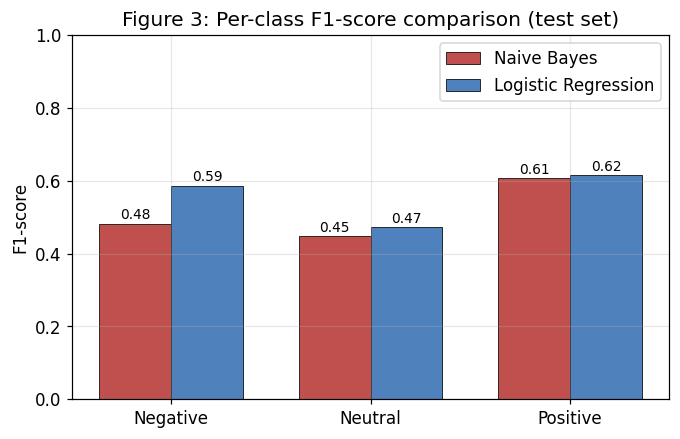

  saved hscf_outputs/figure_4_per_class_precision.png


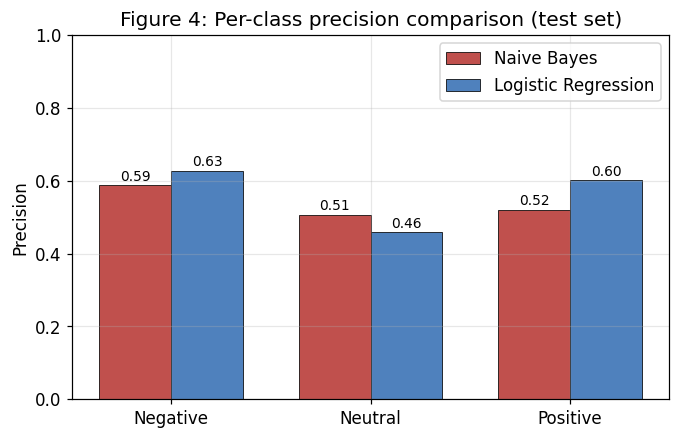

In [20]:
table_6 = pd.DataFrame({
    "Class": [c.capitalize() for c in LABEL_NAMES],
    "NB F1":        [round(nb_rep[c]["f1-score"], 2) for c in LABEL_NAMES],
    "LR F1":        [round(lr_rep[c]["f1-score"], 2) for c in LABEL_NAMES],
    "NB Precision": [round(nb_rep[c]["precision"], 2) for c in LABEL_NAMES],
    "LR Precision": [round(lr_rep[c]["precision"], 2) for c in LABEL_NAMES],
})
save_table(table_6, "table_VI_per_class", "TABLE VI: Per-Class F1-Score and Precision Comparison (Test Set)")

def grouped_bar(nb_vals, lr_vals, ylabel, title, fname):
    x = np.arange(3); w = 0.36
    fig, ax = plt.subplots(figsize=(7, 4.3))
    b1 = ax.bar(x - w/2, nb_vals, w, label="Naive Bayes", color="#c0504d", edgecolor="black", linewidth=0.5)
    b2 = ax.bar(x + w/2, lr_vals, w, label="Logistic Regression", color="#4f81bd", edgecolor="black", linewidth=0.5)
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012,
                    f"{b.get_height():.2f}", ha="center", fontsize=9)
    ax.set_xticks(x, [c.capitalize() for c in LABEL_NAMES])
    ax.set_ylabel(ylabel); ax.set_ylim(0, 1.0); ax.set_title(title); ax.legend()
    save_fig(fig, fname); plt.show()

grouped_bar([nb_rep[c]["f1-score"] for c in LABEL_NAMES],
            [lr_rep[c]["f1-score"] for c in LABEL_NAMES],
            "F1-score", "Figure 3: Per-class F1-score comparison (test set)", "figure_3_per_class_f1")
grouped_bar([nb_rep[c]["precision"] for c in LABEL_NAMES],
            [lr_rep[c]["precision"] for c in LABEL_NAMES],
            "Precision", "Figure 4: Per-class precision comparison (test set)", "figure_4_per_class_precision")

## 11. Micro-averaged ROC analysis (Figure 5)

  saved hscf_outputs/figure_5_roc_curves.png


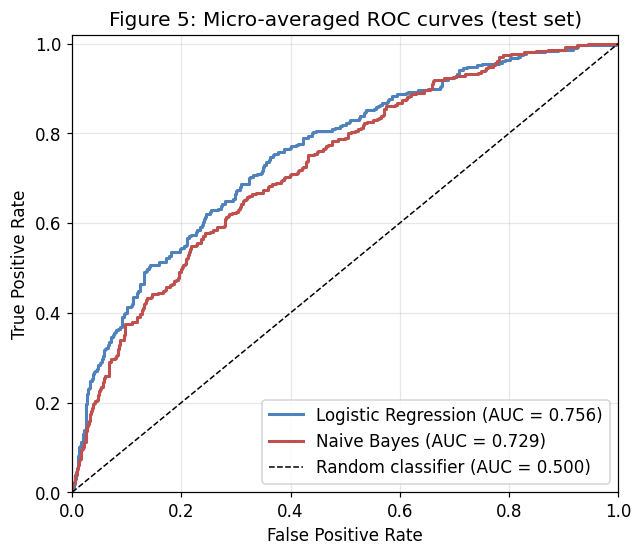

Micro-averaged ROC-AUC: {'Logistic Regression': np.float64(0.7557), 'Naive Bayes': np.float64(0.7293)}


In [21]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_data = {}
fig, ax = plt.subplots(figsize=(6.4, 5.4))
for name, model, colour in [("Logistic Regression", lr_model, "#4f81bd"),
                            ("Naive Bayes", nb_model, "#c0504d")]:
    proba = model.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), proba.ravel())
    a = auc(fpr, tpr)
    roc_data[name] = a
    ax.plot(fpr, tpr, color=colour, lw=2, label=f"{name} (AUC = {a:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier (AUC = 0.500)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 5: Micro-averaged ROC curves (test set)")
ax.legend(loc="lower right"); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
save_fig(fig, "figure_5_roc_curves"); plt.show()

RESULTS["roc_auc"] = {k: round(v, 4) for k, v in roc_data.items()}
print("Micro-averaged ROC-AUC:", RESULTS["roc_auc"])

## 12. Five-fold stratified cross-validation (Table VII) and paired t-test

Cross-validation runs on the combined train + validation partitions (2,790 samples) with the
tuned hyperparameters. The held-out test set is never touched here.

In [22]:
cv_texts  = np.concatenate([X_train_txt, X_val_txt])
cv_labels = np.concatenate([y_train, y_val])
print(f"Cross-validation pool: {len(cv_texts)} samples")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_scores = {"Naive Bayes": [], "Logistic Regression": []}

for k, (tr_idx, te_idx) in enumerate(skf.split(cv_texts, cv_labels), start=1):
    vec = TfidfVectorizer(**TFIDF_KW)                 # refit per fold: no leakage
    Xtr = vec.fit_transform(cv_texts[tr_idx]); Xte = vec.transform(cv_texts[te_idx])
    ytr, yte = cv_labels[tr_idx], cv_labels[te_idx]
    for name, model in [("Naive Bayes", MultinomialNB(alpha=BEST_ALPHA)),
                        ("Logistic Regression", LogisticRegression(
                            C=BEST_C, class_weight=BEST_CW, solver="lbfgs",
                            max_iter=2000, random_state=RANDOM_STATE))]:
        model.fit(Xtr, ytr); pred = model.predict(Xte)
        p, r, f, _ = precision_recall_fscore_support(yte, pred, average="macro", zero_division=0)
        fold_scores[name].append({"accuracy": accuracy_score(yte, pred),
                                  "precision": p, "recall": r, "f1": f})
    print(f"  fold {k}/{N_FOLDS} done")

rows = []
for name, folds in fold_scores.items():
    arr = {m: np.array([f[m] for f in folds]) for m in ("accuracy", "precision", "recall", "f1")}
    rows.append({
        "Model": name,
        "Accuracy":            f"{arr['accuracy'].mean()*100:.2f}% +/- {arr['accuracy'].std(ddof=1)*100:.2f}%",
        "Precision (Macro)":   f"{arr['precision'].mean():.4f} +/- {arr['precision'].std(ddof=1):.4f}",
        "Recall (Macro)":      f"{arr['recall'].mean():.4f} +/- {arr['recall'].std(ddof=1):.4f}",
        "F1-Score (Macro)":    f"{arr['f1'].mean():.4f} +/- {arr['f1'].std(ddof=1):.4f}",
    })
save_table(pd.DataFrame(rows), "table_VII_cross_validation",
           f"\nTABLE VII: {N_FOLDS}-Fold Stratified Cross-Validation (Mean +/- Std)")

nb_acc = np.array([f["accuracy"] for f in fold_scores["Naive Bayes"]])
lr_acc = np.array([f["accuracy"] for f in fold_scores["Logistic Regression"]])
t_stat, p_val = stats.ttest_rel(lr_acc, nb_acc)
verdict = "statistically significant" if p_val < 0.05 else "not statistically significant"
print(f"\nPaired t-test on per-fold accuracy (LR vs MNB): "
      f"t({N_FOLDS-1}) = {t_stat:.2f}, p = {p_val:.4f} -> {verdict} at alpha = 0.05")
RESULTS["cv_ttest"] = {"t": float(t_stat), "p": float(p_val)}
RESULTS["cv_mean_acc"] = {"Naive Bayes": float(nb_acc.mean()),
                          "Logistic Regression": float(lr_acc.mean())}

Cross-validation pool: 2790 samples
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done

TABLE VII: 5-Fold Stratified Cross-Validation (Mean +/- Std)


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Naive Bayes,51.61% +/- 1.79%,0.5026 +/- 0.0211,0.4865 +/- 0.0197,0.4854 +/- 0.0213
1,Logistic Regression,56.70% +/- 2.21%,0.5552 +/- 0.0217,0.5535 +/- 0.0212,0.5539 +/- 0.0214



Paired t-test on per-fold accuracy (LR vs MNB): t(4) = 7.27, p = 0.0019 -> statistically significant at alpha = 0.05


## 13. Transformer baseline: fine-tuned mBERT (Tables VIII and IX, Figures 6 and 7)

`bert-base-multilingual-cased` fine-tuned on the identical split: max sequence length 128,
4 epochs, AdamW at 2e-5, batch size 16, weight decay 0.01, 10% linear warm-up, and a
class-weighted cross-entropy loss mirroring `class_weight='balanced'`. The checkpoint with the
best **validation macro-F1** is kept; the test set is evaluated exactly once.

If `torch`/`transformers` are unavailable, the model weights cannot be downloaded, or
`RUN_MBERT = False`, this section is skipped and the notebook continues with the two
classical models.

In [23]:
mbert_results = None
SKIP_REASON = None

if not RUN_MBERT:
    SKIP_REASON = "RUN_MBERT is set to False"
elif not (HAS_TORCH and HAS_TRANSFORMERS):
    SKIP_REASON = "torch and/or transformers not available"

if SKIP_REASON:
    print(f"Skipping the mBERT section: {SKIP_REASON}.")
else:
    try:
        import torch
        from torch.utils.data import TensorDataset, DataLoader
        from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

        torch.manual_seed(RANDOM_STATE)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(RANDOM_STATE)
        device = torch.device("cuda" if torch.cuda.is_available() else
                              ("mps" if getattr(torch.backends, "mps", None)
                               and torch.backends.mps.is_available() else "cpu"))
        print(f"Device: {device}")
        if device.type == "cpu":
            print("No GPU detected - fine-tuning on CPU will take roughly 30-50 minutes.")
            print("Tip: Runtime -> Change runtime type -> T4 GPU, then re-run.")

        tok = AutoTokenizer.from_pretrained(MBERT_MODEL)

        def encode(texts, labels):
            enc = tok(list(texts), truncation=True, padding="max_length",
                      max_length=MBERT_MAXLEN, return_tensors="pt")
            return TensorDataset(enc["input_ids"], enc["attention_mask"],
                                 torch.tensor(np.asarray(labels), dtype=torch.long))

        dl_train = DataLoader(encode(X_train_txt, y_train), batch_size=MBERT_BATCH, shuffle=True)
        dl_val   = DataLoader(encode(X_val_txt,   y_val),   batch_size=MBERT_BATCH * 2)
        dl_test  = DataLoader(encode(X_test_txt,  y_test),  batch_size=MBERT_BATCH * 2)

        model = AutoModelForSequenceClassification.from_pretrained(
            MBERT_MODEL, num_labels=len(LABEL_NAMES)).to(device)

        counts = np.bincount(y_train, minlength=len(LABEL_NAMES)).astype(float)
        counts[counts == 0] = 1.0
        weights = torch.tensor(len(y_train) / (len(LABEL_NAMES) * counts),
                               dtype=torch.float, device=device)
        loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
        print("Class weights:", dict(zip(LABEL_NAMES, np.round(weights.cpu().numpy(), 3))))

        opt = torch.optim.AdamW(model.parameters(), lr=MBERT_LR, weight_decay=MBERT_WD)
        total_steps = len(dl_train) * MBERT_EPOCHS
        sched = get_linear_schedule_with_warmup(opt, int(MBERT_WARMUP * total_steps), total_steps)

        @torch.no_grad()
        def infer(loader):
            model.eval()
            preds, golds = [], []
            for ids, mask, lab in loader:
                logits = model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
                preds.append(logits.argmax(-1).cpu().numpy()); golds.append(lab.numpy())
            return np.concatenate(preds), np.concatenate(golds)

        best_f1, best_state = -1.0, None
        for epoch in range(1, MBERT_EPOCHS + 1):
            model.train(); running, t_ep = 0.0, time.time()
            for step, (ids, mask, lab) in enumerate(dl_train, start=1):
                opt.zero_grad()
                logits = model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
                loss = loss_fn(logits, lab.to(device))
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step(); running += loss.item()
                if step % 40 == 0:
                    print(f"    epoch {epoch} step {step}/{len(dl_train)} loss {running/step:.4f}")
            vp, vg = infer(dl_val)
            _, _, vf1, _ = precision_recall_fscore_support(vg, vp, average="macro", zero_division=0)
            print(f"  epoch {epoch}: train loss {running/len(dl_train):.4f} | "
                  f"val acc {accuracy_score(vg, vp):.4f} | val macro-F1 {vf1:.4f} "
                  f"| {time.time()-t_ep:.0f}s")
            if vf1 > best_f1:
                best_f1 = vf1
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                print("    (best checkpoint so far - retained)")

        if best_state is not None:
            model.load_state_dict(best_state)
        tp, tg = infer(dl_test)
        p, r, f, _ = precision_recall_fscore_support(tg, tp, average="macro", zero_division=0)
        mbert_results = {"accuracy": accuracy_score(tg, tp), "precision": p,
                         "recall": r, "f1": f, "pred": tp, "gold": tg, "best_val_f1": best_f1}
        print(f"\nmBERT test accuracy {mbert_results['accuracy']*100:.2f}% | "
              f"macro-F1 {mbert_results['f1']:.4f}")
        RESULTS["mbert_test"] = {k: float(v) for k, v in mbert_results.items()
                                 if k in ("accuracy", "precision", "recall", "f1")}
    except Exception as exc:
        SKIP_REASON = f"{type(exc).__name__}: {exc}"
        print(f"\nmBERT stage failed and was skipped -> {SKIP_REASON}")
        print("The classical results above are unaffected.")
        mbert_results = None

Device: cuda


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weights: {'negative': np.float32(1.116), 'neutral': np.float32(1.186), 'positive': np.float32(0.793)}
    epoch 1 step 40/155 loss 1.0997
    epoch 1 step 80/155 loss 1.0917
    epoch 1 step 120/155 loss 1.0638
  epoch 1: train loss 1.0548 | val acc 0.5000 | val macro-F1 0.4653 | 57s
    (best checkpoint so far - retained)
    epoch 2 step 40/155 loss 0.9410
    epoch 2 step 80/155 loss 0.9193
    epoch 2 step 120/155 loss 0.9010
  epoch 2: train loss 0.8880 | val acc 0.5419 | val macro-F1 0.5329 | 59s
    (best checkpoint so far - retained)
    epoch 3 step 40/155 loss 0.7227
    epoch 3 step 80/155 loss 0.6995
    epoch 3 step 120/155 loss 0.6962
  epoch 3: train loss 0.7010 | val acc 0.6065 | val macro-F1 0.5987 | 60s
    (best checkpoint so far - retained)
    epoch 4 step 40/155 loss 0.5968
    epoch 4 step 80/155 loss 0.5775
    epoch 4 step 120/155 loss 0.5776
  epoch 4: train loss 0.5727 | val acc 0.5968 | val macro-F1 0.5944 | 60s

mBERT test accuracy 57.74% | macro-F1 0

TABLE VIII: Three-Way Model Comparison (Test Set)


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Naive Bayes,53.23%,0.5386,0.5126,0.5122
1,Logistic Regression,56.45%,0.5626,0.5570,0.5587
2,mBERT,57.74%,0.5805,0.5767,0.5708



TABLE IX: Classification Report of mBERT (Test Set)


,Class,Precision,Recall,F1-Score,Support
0,negative,0.5263,0.7143,0.6061,98
1,neutral,0.5385,0.4667,0.5000,90
2,positive,0.6768,0.5492,0.6063,122
3,accuracy,—,—,0.5774,310
4,macro avg,0.5805,0.5767,0.5708,310
5,weighted avg,0.5891,0.5774,0.5754,310


  saved hscf_outputs/figure_6_three_way_accuracy.png


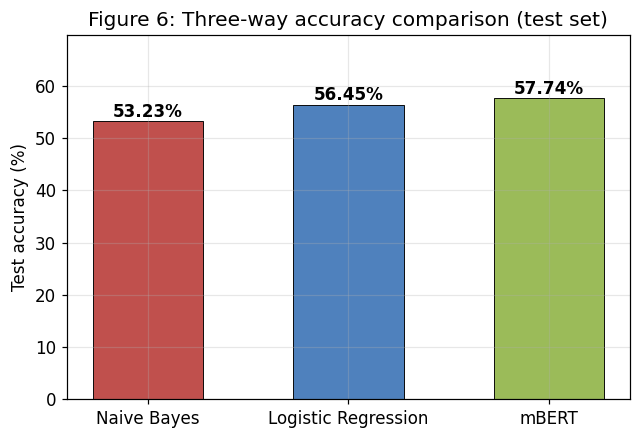

  saved hscf_outputs/figure_7_mbert_confusion.png


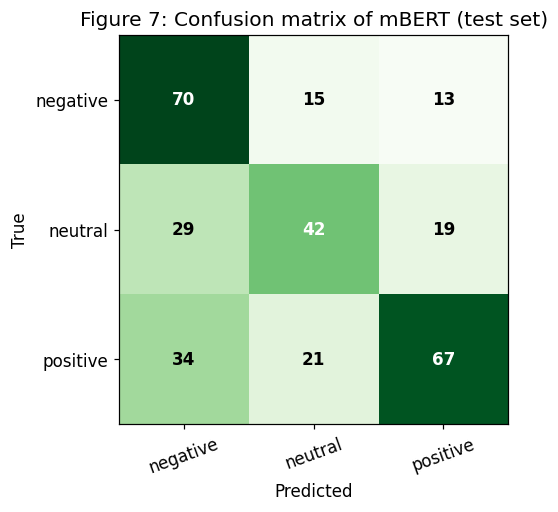

In [24]:
if mbert_results is None:
    print("No mBERT results - Tables VIII/IX and Figures 6/7 are skipped.")
    table_8 = pd.DataFrame({
        "Model": ["Naive Bayes", "Logistic Regression"],
        "Accuracy": [f"{nb_test['accuracy']*100:.2f}%", f"{lr_test['accuracy']*100:.2f}%"],
        "Precision (Macro)": [f"{nb_test['precision']:.4f}", f"{lr_test['precision']:.4f}"],
        "Recall (Macro)":    [f"{nb_test['recall']:.4f}",    f"{lr_test['recall']:.4f}"],
        "F1-Score (Macro)":  [f"{nb_test['f1']:.4f}",        f"{lr_test['f1']:.4f}"],
    })
    save_table(table_8, "table_VIII_model_comparison", "Model comparison (test set, classical models only)")
else:
    table_8 = pd.DataFrame({
        "Model": ["Naive Bayes", "Logistic Regression", "mBERT"],
        "Accuracy": [f"{m['accuracy']*100:.2f}%" for m in (nb_test, lr_test, mbert_results)],
        "Precision (Macro)": [f"{m['precision']:.4f}" for m in (nb_test, lr_test, mbert_results)],
        "Recall (Macro)":    [f"{m['recall']:.4f}"    for m in (nb_test, lr_test, mbert_results)],
        "F1-Score (Macro)":  [f"{m['f1']:.4f}"        for m in (nb_test, lr_test, mbert_results)],
    })
    save_table(table_8, "table_VIII_model_comparison", "TABLE VIII: Three-Way Model Comparison (Test Set)")

    print()
    report_table(mbert_results["gold"], mbert_results["pred"],
                 "TABLE IX: Classification Report of mBERT (Test Set)", "table_IX_mbert_report")

    accs = [nb_test["accuracy"]*100, lr_test["accuracy"]*100, mbert_results["accuracy"]*100]
    fig, ax = plt.subplots(figsize=(6.6, 4.3))
    bars = ax.bar(["Naive Bayes", "Logistic Regression", "mBERT"], accs,
                  color=["#c0504d", "#4f81bd", "#9bbb59"], width=0.55,
                  edgecolor="black", linewidth=0.6)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.8, f"{b.get_height():.2f}%",
                ha="center", fontweight="bold")
    ax.set_ylabel("Test accuracy (%)"); ax.set_ylim(0, max(accs) + 12)
    ax.set_title("Figure 6: Three-way accuracy comparison (test set)")
    save_fig(fig, "figure_6_three_way_accuracy"); plt.show()

    cm_mb = confusion_matrix(mbert_results["gold"], mbert_results["pred"], labels=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(5.4, 4.6))
    draw_cm(ax, cm_mb, "Figure 7: Confusion matrix of mBERT (test set)", "Greens")
    save_fig(fig, "figure_7_mbert_confusion"); plt.show()

## 14. Inference on unseen text and model export

In [25]:
SAMPLES = [
    "यह फिल्म बहुत अच्छी है और acting शानदार है",
    "कहानी बेहद कमजोर थी और निर्देशन निराशाजनक रहा",
    "फिल्म ठीक ठाक है, कुछ दृश्य अच्छे हैं",
]

def predict_sentiment(texts, model=None, name="Logistic Regression"):
    model = model or lr_model
    feats = vectorizer.transform([clean(t) for t in texts])
    preds = model.predict(feats)
    probs = model.predict_proba(feats)
    rows = []
    for t, pr, pb in zip(texts, preds, probs):
        rows.append({"Text": t[:60] + ("..." if len(t) > 60 else ""),
                     f"{name} prediction": LABEL_NAMES[pr],
                     **{f"P({c})": round(float(pb[i]), 3) for i, c in enumerate(LABEL_NAMES)}})
    return pd.DataFrame(rows)

save_table(predict_sentiment(SAMPLES), "sample_predictions", "Sample predictions (Logistic Regression):")

joblib.dump(vectorizer, OUTDIR / "tfidf_vectorizer.pkl")
joblib.dump(lr_model,   OUTDIR / "logistic_regression_model.pkl")
joblib.dump(nb_model,   OUTDIR / "naive_bayes_model.pkl")
print("\nSaved: tfidf_vectorizer.pkl, logistic_regression_model.pkl, naive_bayes_model.pkl")
print("Reload later with:  joblib.load('hscf_outputs/logistic_regression_model.pkl')")

Sample predictions (Logistic Regression):


,Text,Logistic Regression prediction,P(negative),P(neutral),P(positive)
0,यह फिल्म बहुत अच्छी है और acting शानदार है,positive,0.272,0.186,0.542
1,कहानी बेहद कमजोर थी और निर्देशन निराशाजनक रहा,negative,0.553,0.342,0.105
2,"फिल्म ठीक ठाक है, कुछ दृश्य अच्छे हैं",positive,0.115,0.141,0.744



Saved: tfidf_vectorizer.pkl, logistic_regression_model.pkl, naive_bayes_model.pkl
Reload later with:  joblib.load('hscf_outputs/logistic_regression_model.pkl')


## 15. Summary and download

Writes a JSON record of every metric, zips the whole output folder, and triggers a browser
download when running on Google Colab.

In [26]:
print("=" * 72)
print("HINDI SENTIMENT CLASSIFICATION FRAMEWORK - SUMMARY")
print("=" * 72)
print(f"Data source        : {SOURCE}" + ("  [DEMO MODE - not the real dataset]" if DEMO_MODE else ""))
print(f"Splits             : {len(train_df)} train / {len(val_df)} val / {len(test_df)} test")
print(f"TF-IDF vocabulary  : {RESULTS['vocab_size']:,} features (unigram + bigram)")
print(f"Tuned MNB          : alpha = {BEST_ALPHA}")
print(f"Tuned LR           : C = {BEST_C}, class_weight = {BEST_CW}")
print("-" * 72)
print(f"1. LR test accuracy {lr_test['accuracy']*100:.2f}% vs MNB {nb_test['accuracy']*100:.2f}% "
      f"({(lr_test['accuracy']-nb_test['accuracy'])*100:+.2f} pp)")
print(f"2. Macro recall / F1 - LR {lr_test['recall']:.4f} / {lr_test['f1']:.4f}, "
      f"MNB {nb_test['recall']:.4f} / {nb_test['f1']:.4f}")
best_cls = max(LABEL_NAMES, key=lambda c: lr_rep[c]["f1-score"])
worst_cls = min(LABEL_NAMES, key=lambda c: lr_rep[c]["f1-score"])
print(f"3. Easiest class: {best_cls} (LR F1 = {lr_rep[best_cls]['f1-score']:.2f}); "
      f"hardest: {worst_cls} (LR F1 = {lr_rep[worst_cls]['f1-score']:.2f})")
print(f"4. Micro ROC-AUC - LR {RESULTS['roc_auc']['Logistic Regression']:.3f} vs "
      f"MNB {RESULTS['roc_auc']['Naive Bayes']:.3f}")
print(f"5. {N_FOLDS}-fold CV accuracy - LR {RESULTS['cv_mean_acc']['Logistic Regression']*100:.2f}% vs "
      f"MNB {RESULTS['cv_mean_acc']['Naive Bayes']*100:.2f}%, "
      f"paired t-test p = {RESULTS['cv_ttest']['p']:.4f}")
if mbert_results:
    print(f"6. Fine-tuned mBERT {mbert_results['accuracy']*100:.2f}% accuracy, "
          f"macro-F1 {mbert_results['f1']:.4f} (best of the three)")
else:
    print(f"6. mBERT not run ({SKIP_REASON})")
print("=" * 72)

RESULTS.update({"source": SOURCE, "demo_mode": bool(DEMO_MODE),
                "splits": {"train": len(train_df), "val": len(val_df), "test": len(test_df)}})
(OUTDIR / "results.json").write_text(json.dumps(RESULTS, indent=2, default=float), encoding="utf-8")

zip_path = "hscf_outputs.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)
shutil.make_archive("hscf_outputs", "zip", OUTDIR)
print(f"\nBundled {len(list(OUTDIR.iterdir()))} files into {zip_path}")
for f in sorted(OUTDIR.iterdir()):
    print(f"  {f.name}")

try:
    from google.colab import files as colab_files
    colab_files.download(zip_path)
except Exception:
    print(f"\n(Not on Colab - the zip is on disk at {os.path.abspath(zip_path)})")

HINDI SENTIMENT CLASSIFICATION FRAMEWORK - SUMMARY
Data source        : Local train/valid/test files
Splits             : 2480 train / 310 val / 310 test
TF-IDF vocabulary  : 30,228 features (unigram + bigram)
Tuned MNB          : alpha = 0.05
Tuned LR           : C = 1.0, class_weight = balanced
------------------------------------------------------------------------
1. LR test accuracy 56.45% vs MNB 53.23% (+3.23 pp)
2. Macro recall / F1 - LR 0.5570 / 0.5587, MNB 0.5126 / 0.5122
3. Easiest class: positive (LR F1 = 0.62); hardest: neutral (LR F1 = 0.47)
4. Micro ROC-AUC - LR 0.756 vs MNB 0.729
5. 5-fold CV accuracy - LR 56.70% vs MNB 51.61%, paired t-test p = 0.0019
6. Fine-tuned mBERT 57.74% accuracy, macro-F1 0.5708 (best of the three)

Bundled 23 files into hscf_outputs.zip
  class_distribution.csv
  figure_1_accuracy_comparison.png
  figure_2_confusion_matrices.png
  figure_3_per_class_f1.png
  figure_4_per_class_precision.png
  figure_5_roc_curves.png
  figure_6_three_way_accurac

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

### Notes on reproducing the published numbers

* The paper reports **59.35%** test accuracy for mBERT, **56.13%** for tuned Logistic Regression
  and **52.90%** for tuned Naive Bayes, with selected hyperparameters `alpha = 0.05` and
  `C = 1.0, class_weight = 'balanced'`. Re-running this notebook on the real dataset should land
  on those classical figures exactly; mBERT will vary by roughly ±1 point across runs because
  GPU kernel non-determinism and dropout ordering are not fully seedable.
* If the loader falls back to `DEMO_MODE`, the pipeline is still exercised end to end but the
  numbers are meaningless as a reproduction — download the dataset from the Kaggle link and set
  `LOCAL_DATA_DIR` to fix that.
* Dataset: IIT Patna Movie Reviews Hindi Sentiment Analysis (Kaggle / `ai4bharat/IndicGLUE`,
  configuration `iitp-mr.hi`).